In [1]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np

np.set_printoptions(suppress=True)

In [2]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [3]:
compact = True

In [6]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading combined_20250121174047.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
422ad950-6e0e-49cd-a70b-3663528e6351,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.5310,0.015930,0,"[7, 5, 0, 0, 0]",1299.0,NaN
97e5eab0-d18f-495d-89f7-3ad4bd347d9a,422ad950-6e0e-49cd-a70b-3663528e6351,"[4, 48, 49]","[96, 96]",0,"[0, 0]","[4, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],check,0,0.5373,0.021492,0,"[10, 9, 7, 5, 4]",1299.0,NaN
483e68f6-2387-4271-a173-98e565f0e6b9,97e5eab0-d18f-495d-89f7-3ad4bd347d9a,"[4, 48, 49]","[96, 92]",0,"[0, 4]","[4, 8]","[True, True]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],raise,12,0.5373,0.032238,0,"[10, 9, 7, 5, 4]",1299.0,NaN
809614b3-d6e9-441f-ada1-4c7c9a0e7302,None,[],"[104, 88]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.4354,0.017416,0,"[4, 0, 0, 0, 0]",588.0,NaN
a9d8f8a4-a61a-4b82-94df-317e29250da9,809614b3-d6e9-441f-ada1-4c7c9a0e7302,"[47, 23, 11]","[104, 84]",0,"[0, 4]","[4, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],fold,0,0.3273,0.019638,0,"[11, 10, 8, 4, 0]",588.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1461f599-db6a-4420-9cfc-b65390b59f66,37ae60c2-2a9f-46fa-8ce5-5a4234c32be3,"[12, 3, 6]","[34, 150]",1,"[0, 0]","[8, 8]","[False, False]","[False, False]",1,4,...,HumanMocker,[Max Mekker],check,0,0.6978,0.055824,1,"[12, 6, 4, 3, 0]",1239.0,NaN
e3f41993-1619-4a9a-a3dd-d81568381da8,1461f599-db6a-4420-9cfc-b65390b59f66,"[12, 3, 6, 32]","[34, 150]",1,"[0, 0]","[8, 8]","[False, False]","[False, False]",1,4,...,HumanMocker,[Max Mekker],check,0,0.7707,0.061656,2,"[12, 6, 4, 0, 0]",1239.0,NaN
b9a414be-e05b-4983-8256-890bfd45b476,e3f41993-1619-4a9a-a3dd-d81568381da8,"[12, 3, 6, 32]","[23, 150]",1,"[11, 0]","[19, 8]","[True, True]","[False, False]",1,4,...,HumanMocker,[Max Mekker],call,11,0.7707,0.104044,2,"[12, 6, 4, 0, 0]",1239.0,NaN


In [5]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [6]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [7]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,p,relative_ev,stage,player_name,human,opponent_name,n_players,is_all_in,hand_group,hand_suited
7a4496cd-e0bb-410b-a4b9-4ad91cfefe4e,0,0,0,0,0,0,0,0,0,0,...,0.6086,0.018258,preflop,Henning,True,Max Mekker,2,False,26.0,False
ecaa4d10-63d6-4d6e-babb-0d84d5f1a7b1,0,0,0,0,0,0,0,0,0,0,...,0.5449,0.016347,preflop,Max Mekker,False,Adrian,2,False,48.0,False
6ed6f9ed-7792-4a22-a46d-b8009a62703a,0,0,0,0,0,0,0,0,0,0,...,0.5579,0.016737,preflop,Adrian,False,Max Mekker,2,False,30.0,False
09d9346d-933e-461b-82f4-48be7be6de8c,0,0,0,0,0,0,0,0,0,0,...,0.5993,0.035958,preflop,Adrian,False,Max Mekker,2,False,7.0,False
38e77ad7-87f2-4749-8223-c45fd30f51aa,0,0,0,0,0,0,0,0,0,0,...,0.5874,0.017622,preflop,Adrian,False,Max Mekker,2,False,10.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6230a112-d54e-4ae0-9134-51e300c53cd4,54,0,0,0,0,0,0,0,0,0,...,0.7980,0.446880,river,Max Mekker,False,Adrian,2,True,13.0,False
6165563904,0,51,0,0,0,6,0,0,0,0,...,0.7229,0.477114,flop,Arin,True,,2,False,NaN,None
6165442032,0,69,0,0,0,6,0,0,0,0,...,0.7229,0.603621,flop,Arin,True,,2,True,NaN,None
6165562320,0,69,0,0,0,6,13,0,0,0,...,0.7730,0.695700,turn,Arin,True,,2,True,NaN,None


In [8]:
# Drop any rows where hand_group is NaN
df = df.dropna(subset=["hand_group"])
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,p,relative_ev,stage,player_name,human,opponent_name,n_players,is_all_in,hand_group,hand_suited
7a4496cd-e0bb-410b-a4b9-4ad91cfefe4e,0,0,0,0,0,0,0,0,0,0,...,0.6086,0.018258,preflop,Henning,True,Max Mekker,2,False,26.0,False
ecaa4d10-63d6-4d6e-babb-0d84d5f1a7b1,0,0,0,0,0,0,0,0,0,0,...,0.5449,0.016347,preflop,Max Mekker,False,Adrian,2,False,48.0,False
6ed6f9ed-7792-4a22-a46d-b8009a62703a,0,0,0,0,0,0,0,0,0,0,...,0.5579,0.016737,preflop,Adrian,False,Max Mekker,2,False,30.0,False
09d9346d-933e-461b-82f4-48be7be6de8c,0,0,0,0,0,0,0,0,0,0,...,0.5993,0.035958,preflop,Adrian,False,Max Mekker,2,False,7.0,False
38e77ad7-87f2-4749-8223-c45fd30f51aa,0,0,0,0,0,0,0,0,0,0,...,0.5874,0.017622,preflop,Adrian,False,Max Mekker,2,False,10.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1c3a15ba-3f56-4c62-a5b9-2272f33a44f7,6,0,6,0,0,4,10,0,0,0,...,0.2242,0.062776,river,Max Mekker,False,Adrian,2,True,19.0,False
d3887562-e8a4-492d-a7e4-f7fca654346a,0,0,0,0,0,6,9,15,0,0,...,0.8086,0.375999,river,Adrian,False,Max Mekker,2,False,26.0,False
db05df50-3a6c-463d-b383-9b2a6c5a3a6a,0,0,0,30,0,6,8,10,0,0,...,0.9913,0.589823,river,Mr. Henning,False,Max Mekker,2,False,48.0,True
a8386401-03d8-4061-a988-cf541768297e,6,9,0,0,0,0,8,25,0,0,...,0.4445,0.260032,river,Adrian,False,Max Mekker,2,True,67.0,False


## Examine data

In [9]:
dict(df.dtypes)

{'raise_preflop': dtype('int64'),
 'raise_flop': dtype('int64'),
 'raise_turn': dtype('int64'),
 'raise_river': dtype('int64'),
 'raise_showdown': dtype('int64'),
 'call_preflop': dtype('int64'),
 'call_flop': dtype('int64'),
 'call_turn': dtype('int64'),
 'call_river': dtype('int64'),
 'call_showdown': dtype('int64'),
 'check_preflop': dtype('int64'),
 'check_flop': dtype('int64'),
 'check_turn': dtype('int64'),
 'check_river': dtype('int64'),
 'check_showdown': dtype('int64'),
 'opponent_raise_preflop': dtype('int64'),
 'opponent_raise_flop': dtype('int64'),
 'opponent_raise_turn': dtype('int64'),
 'opponent_raise_river': dtype('int64'),
 'opponent_raise_showdown': dtype('int64'),
 'opponent_call_preflop': dtype('int64'),
 'opponent_call_flop': dtype('int64'),
 'opponent_call_turn': dtype('int64'),
 'opponent_call_river': dtype('int64'),
 'opponent_call_showdown': dtype('int64'),
 'opponent_check_preflop': dtype('int64'),
 'opponent_check_flop': dtype('int64'),
 'opponent_check_turn'

<Axes: title={'center': 'Occurrences of each hand group'}, xlabel='hand_group'>

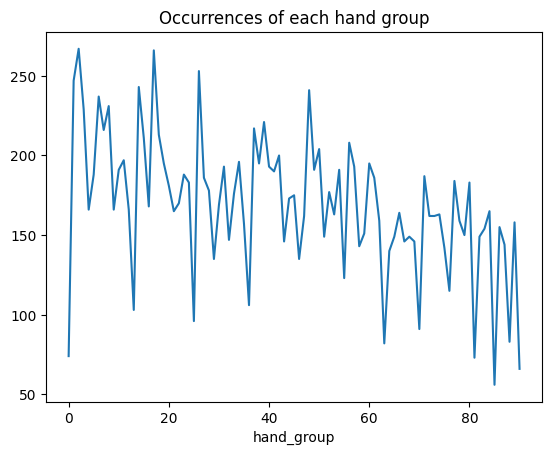

In [10]:
df.groupby("hand_group").size().plot(title="Occurrences of each hand group")

In [11]:
df.groupby("human").size()

human
False    12260
True      3151
dtype: int64

In [12]:
df.groupby("player_name").size().sort_values(ascending=False)

player_name
Max Mekker     6007
Adrian         4702
Tord           1339
Mr. Tord        638
Mr. Arin        535
Mr. Henning     378
t               364
Finn            324
Jacob           296
Arin            292
Henning         291
Kristian         95
Syver            84
Jakob            48
Alun             18
dtype: int64

<Axes: title={'center': 'Occurrences of each card on the table'}>

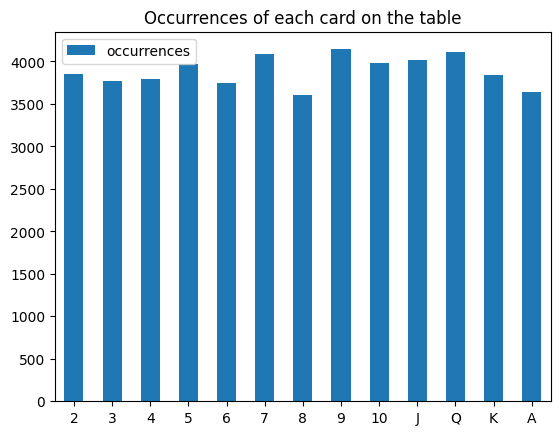

In [13]:
from cpp_poker.cpp_poker import Card

card_occurences_on_table = []
for value in Card.VALUES:
    card_occurences_on_table.append(df[f"n_{value}_on_table"].sum())
pd.DataFrame(dict(zip(Card.VALUES, card_occurences_on_table)), index=["occurrences"]).T.plot(
    title="Occurrences of each card on the table", kind="bar", rot=0
)

## Training

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
X = df.drop(
    [
        # These must be dropped to avoid data leakage
        "excess_rank",
        "game_id",
        "p",
        "relative_ev",
        "hand_group",
        "hand_suited",

        # Drop these columns to avoid overfitting
        "player_name",
        "opponent_name",
    ],
    axis=1,
)
Y = df[["hand_group", "hand_suited"]]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [16]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,n_♥_on_table,n_♦_on_table,n_♣_on_table,n_♠_on_table,action,amount,stage,human,n_players,is_all_in
7a4496cd-e0bb-410b-a4b9-4ad91cfefe4e,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,True,2,False
ecaa4d10-63d6-4d6e-babb-0d84d5f1a7b1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,raise,6,preflop,False,2,False
6ed6f9ed-7792-4a22-a46d-b8009a62703a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,False,2,False
09d9346d-933e-461b-82f4-48be7be6de8c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,fold,0,preflop,False,2,False
38e77ad7-87f2-4749-8223-c45fd30f51aa,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,raise,6,preflop,False,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1c3a15ba-3f56-4c62-a5b9-2272f33a44f7,6,0,6,0,0,4,10,0,0,0,...,12,0,1,2,check,0,river,False,2,True
d3887562-e8a4-492d-a7e4-f7fca654346a,0,0,0,0,0,6,9,15,0,0,...,10,8,6,0,fold,0,river,False,2,False
db05df50-3a6c-463d-b383-9b2a6c5a3a6a,0,0,0,30,0,6,8,10,0,0,...,3,14,0,12,call,7,river,False,2,False
a8386401-03d8-4061-a988-cf541768297e,6,9,0,0,0,0,8,25,0,0,...,6,6,0,12,fold,0,river,False,2,True


In [17]:
Y

,hand_group,hand_suited
7a4496cd-e0bb-410b-a4b9-4ad91cfefe4e,26.0,False
ecaa4d10-63d6-4d6e-babb-0d84d5f1a7b1,48.0,False
6ed6f9ed-7792-4a22-a46d-b8009a62703a,30.0,False
09d9346d-933e-461b-82f4-48be7be6de8c,7.0,False
38e77ad7-87f2-4749-8223-c45fd30f51aa,10.0,False
...,...,...
1c3a15ba-3f56-4c62-a5b9-2272f33a44f7,19.0,False
d3887562-e8a4-492d-a7e4-f7fca654346a,26.0,False
db05df50-3a6c-463d-b383-9b2a6c5a3a6a,48.0,True
a8386401-03d8-4061-a988-cf541768297e,67.0,False


In [18]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = [
    "action",
    "stage",
    # "player_name",
    # "opponent_name",
]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "classifier",
            LogisticRegression(
                multi_class="multinomial", solver="lbfgs", max_iter=10_000
            ),
        ),
    ]
)

In [19]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (12215, 53)
Test shape: (3196, 53)


In [20]:
# Only predict hand_group index (not suited) for now
y_train_cls = Y_train["hand_group"]
y_test_cls = Y_test["hand_group"]

In [21]:
# Train the model
model.fit(X_train, y_train_cls)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage'])])),
                ('classifier',
                 LogisticRegression(max_iter=10000,
                                    multi_class='multinomial'))])

In [22]:
# Evaluate the model
accuracy = model.score(X_test, y_test_cls)
print(f"Accuracy: {accuracy}")

Accuracy: 0.015331664580725907


In [23]:
probabilities = model.predict_proba(X_test)
prob_df = pd.DataFrame(probabilities, columns=model.classes_, index=X_test.index)
prob_df["true"] = y_test_cls.values
prob_df["pred"] = model.predict(X_test)
prob_df["correct"] = prob_df["true"] == prob_df["pred"]
prob_df["goodness"] = prob_df.apply(lambda x: x.get(x["true"]) or 0, axis=1)
print("Accuracy", prob_df["correct"].mean())
print("Mean goodness: ", prob_df["goodness"].mean())
prob_df

Accuracy 0.015331664580725907
Mean goodness:  0.012593872784317544


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,85.0,86.0,87.0,88.0,89.0,90.0,true,pred,correct,goodness
6ed6f9ed-7792-4a22-a46d-b8009a62703a,5.742055e-04,0.006665,0.004322,0.007694,0.007877,9.019558e-03,0.008962,0.009717,0.007753,0.007690,...,3.430984e-03,1.977852e-02,0.014030,2.667447e-03,2.032856e-02,5.632979e-03,30.0,62.0,False,1.009977e-02
3e16b1a3-c3bb-4692-8fe4-7f967e027ce1,3.604556e-03,0.011807,0.012729,0.015355,0.012389,1.278310e-02,0.015368,0.018777,0.013241,0.013191,...,3.379258e-03,1.112194e-02,0.011632,3.913224e-03,1.188763e-02,5.201333e-03,43.0,26.0,False,1.047239e-02
f5dc8859-55e4-482c-8897-57bec2091759,8.025736e-03,0.018033,0.017818,0.016199,0.012428,1.403150e-02,0.016301,0.011922,0.018415,0.010484,...,4.905150e-03,1.085597e-02,0.006784,5.642402e-03,7.820584e-03,4.112315e-03,15.0,18.0,False,1.434959e-02
f47a9ca1-e0ea-47cb-9e6e-6a6ce3bf83fe,8.025736e-03,0.018033,0.017818,0.016199,0.012428,1.403150e-02,0.016301,0.011922,0.018415,0.010484,...,4.905150e-03,1.085597e-02,0.006784,5.642402e-03,7.820584e-03,4.112315e-03,73.0,18.0,False,1.041083e-02
08f7fc6f-2b8f-4e31-b165-81c21045516e,5.742055e-04,0.006665,0.004322,0.007694,0.007877,9.019558e-03,0.008962,0.009717,0.007753,0.007690,...,3.430984e-03,1.977852e-02,0.014030,2.667447e-03,2.032856e-02,5.632979e-03,80.0,62.0,False,1.882744e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476aaeba-c893-4e3d-8afd-f3292cf1d926,1.907545e-05,0.000013,0.000044,0.000021,0.000430,1.600991e-08,0.009687,0.048791,0.000191,0.053147,...,7.294692e-04,6.428497e-18,0.000100,1.467368e-04,2.551584e-05,1.506881e-11,54.0,15.0,False,3.612135e-05
389670fd-258b-4c4b-9703-c31359bd1681,2.923004e-08,0.000004,0.004395,0.000518,0.000960,1.051398e-07,0.005463,0.035879,0.121829,0.000951,...,1.087714e-06,5.069310e-20,0.060526,4.605439e-08,2.744981e-04,1.826166e-10,1.0,76.0,False,4.337683e-06
d50ea263-fa39-4a09-ae1b-55440999900a,4.599710e-02,0.009320,0.001050,0.081901,0.000499,2.449063e-04,0.076941,0.005435,0.000270,0.000653,...,3.931763e-10,3.770097e-05,0.000055,3.175634e-06,2.573762e-07,1.057944e-13,9.0,13.0,False,6.526933e-04
2311cd63-3712-4030-8397-ba278d56d483,2.389059e-02,0.000590,0.002381,0.024074,0.024019,1.032697e-04,0.023436,0.000095,0.030313,0.138522,...,3.107440e-07,1.151284e-07,0.000206,3.525076e-08,1.840003e-03,1.294430e-05,19.0,76.0,False,2.661969e-06


In [24]:
# Look at incorrect predictions
print(prob_df[prob_df["correct"] == False].shape[0], "incorrect predictions:")
prob_df[prob_df["correct"] == False]

3147 incorrect predictions:


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,85.0,86.0,87.0,88.0,89.0,90.0,true,pred,correct,goodness
6ed6f9ed-7792-4a22-a46d-b8009a62703a,5.742055e-04,0.006665,0.004322,0.007694,0.007877,9.019558e-03,0.008962,0.009717,0.007753,0.007690,...,3.430984e-03,1.977852e-02,0.014030,2.667447e-03,2.032856e-02,5.632979e-03,30.0,62.0,False,1.009977e-02
3e16b1a3-c3bb-4692-8fe4-7f967e027ce1,3.604556e-03,0.011807,0.012729,0.015355,0.012389,1.278310e-02,0.015368,0.018777,0.013241,0.013191,...,3.379258e-03,1.112194e-02,0.011632,3.913224e-03,1.188763e-02,5.201333e-03,43.0,26.0,False,1.047239e-02
f5dc8859-55e4-482c-8897-57bec2091759,8.025736e-03,0.018033,0.017818,0.016199,0.012428,1.403150e-02,0.016301,0.011922,0.018415,0.010484,...,4.905150e-03,1.085597e-02,0.006784,5.642402e-03,7.820584e-03,4.112315e-03,15.0,18.0,False,1.434959e-02
f47a9ca1-e0ea-47cb-9e6e-6a6ce3bf83fe,8.025736e-03,0.018033,0.017818,0.016199,0.012428,1.403150e-02,0.016301,0.011922,0.018415,0.010484,...,4.905150e-03,1.085597e-02,0.006784,5.642402e-03,7.820584e-03,4.112315e-03,73.0,18.0,False,1.041083e-02
08f7fc6f-2b8f-4e31-b165-81c21045516e,5.742055e-04,0.006665,0.004322,0.007694,0.007877,9.019558e-03,0.008962,0.009717,0.007753,0.007690,...,3.430984e-03,1.977852e-02,0.014030,2.667447e-03,2.032856e-02,5.632979e-03,80.0,62.0,False,1.882744e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476aaeba-c893-4e3d-8afd-f3292cf1d926,1.907545e-05,0.000013,0.000044,0.000021,0.000430,1.600991e-08,0.009687,0.048791,0.000191,0.053147,...,7.294692e-04,6.428497e-18,0.000100,1.467368e-04,2.551584e-05,1.506881e-11,54.0,15.0,False,3.612135e-05
389670fd-258b-4c4b-9703-c31359bd1681,2.923004e-08,0.000004,0.004395,0.000518,0.000960,1.051398e-07,0.005463,0.035879,0.121829,0.000951,...,1.087714e-06,5.069310e-20,0.060526,4.605439e-08,2.744981e-04,1.826166e-10,1.0,76.0,False,4.337683e-06
d50ea263-fa39-4a09-ae1b-55440999900a,4.599710e-02,0.009320,0.001050,0.081901,0.000499,2.449063e-04,0.076941,0.005435,0.000270,0.000653,...,3.931763e-10,3.770097e-05,0.000055,3.175634e-06,2.573762e-07,1.057944e-13,9.0,13.0,False,6.526933e-04
2311cd63-3712-4030-8397-ba278d56d483,2.389059e-02,0.000590,0.002381,0.024074,0.024019,1.032697e-04,0.023436,0.000095,0.030313,0.138522,...,3.107440e-07,1.151284e-07,0.000206,3.525076e-08,1.840003e-03,1.294430e-05,19.0,76.0,False,2.661969e-06


### Compare to XGBoost

In [25]:
from xgboost import XGBClassifier

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "classifier",
            XGBClassifier(),
        ),
    ]
)

In [26]:
cross_validate = False

In [27]:
if cross_validate:
    # Cross validate to find good hyperparameters
    from sklearn.model_selection import GridSearchCV

    # Define the parameter grid
    param_grid = {
        'classifier__n_estimators': [100, 500],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    }

    # Grid search over the XGBRegressor parameters
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train_cls)

    # Best parameters and score
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    
    # Use the best model
    model = grid_search.best_estimator_

In [28]:
# Train the model
model.fit(X_train, y_train_cls)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eva...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [29]:
# Evaluate the model
accuracy = model.score(X_test, y_test_cls)
print(f"Accuracy: {accuracy}")

Accuracy: 0.013454317897371715


In [30]:
probabilities = model.predict_proba(X_test)
prob_df = pd.DataFrame(probabilities, columns=model.classes_, index=X_test.index)
prob_df["true"] = y_test_cls.values
prob_df["pred"] = model.predict(X_test)
prob_df["correct"] = prob_df["true"] == prob_df["pred"]
prob_df["goodness"] = prob_df.apply(lambda x: x.get(x["true"]) or 0, axis=1)
print("Accuracy", prob_df["correct"].mean())
print("Mean goodness: ", prob_df["goodness"].mean())
prob_df

Accuracy 0.013454317897371715
Mean goodness:  0.012843205045997178


,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,true,pred,correct,goodness
6ed6f9ed-7792-4a22-a46d-b8009a62703a,0.000048,0.005315,0.002748,0.007898,0.008042,0.008094,0.007256,0.010725,0.008646,0.007438,...,0.005578,0.018201,0.014313,0.003113,0.019750,0.006274,30.0,82,False,0.012831
3e16b1a3-c3bb-4692-8fe4-7f967e027ce1,0.001903,0.003625,0.009774,0.014612,0.010597,0.011996,0.015929,0.020714,0.014356,0.011324,...,0.001979,0.011628,0.010628,0.002148,0.016991,0.006008,43.0,68,False,0.008467
f5dc8859-55e4-482c-8897-57bec2091759,0.004423,0.021847,0.023175,0.016235,0.012728,0.015249,0.018260,0.011018,0.015727,0.010742,...,0.002888,0.010278,0.006891,0.007017,0.005996,0.002920,15.0,2,False,0.014039
f47a9ca1-e0ea-47cb-9e6e-6a6ce3bf83fe,0.004423,0.021847,0.023175,0.016235,0.012728,0.015249,0.018260,0.011018,0.015727,0.010742,...,0.002888,0.010278,0.006891,0.007017,0.005996,0.002920,73.0,2,False,0.011445
08f7fc6f-2b8f-4e31-b165-81c21045516e,0.000048,0.005315,0.002748,0.007898,0.008042,0.008094,0.007256,0.010725,0.008646,0.007438,...,0.005578,0.018201,0.014313,0.003113,0.019750,0.006274,80.0,82,False,0.017428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476aaeba-c893-4e3d-8afd-f3292cf1d926,0.000392,0.012693,0.017317,0.001945,0.140895,0.001207,0.010162,0.004105,0.007169,0.143442,...,0.000490,0.000820,0.006053,0.002128,0.001791,0.000720,54.0,9,False,0.019710
389670fd-258b-4c4b-9703-c31359bd1681,0.000605,0.000239,0.014561,0.019868,0.002543,0.000224,0.042765,0.001653,0.001861,0.002758,...,0.000240,0.000263,0.000311,0.000545,0.004702,0.000162,1.0,16,False,0.000239
d50ea263-fa39-4a09-ae1b-55440999900a,0.002824,0.001603,0.011536,0.001215,0.000799,0.000104,0.000087,0.000739,0.000197,0.004951,...,0.000012,0.000422,0.000048,0.000666,0.002786,0.000005,9.0,13,False,0.004951
2311cd63-3712-4030-8397-ba278d56d483,0.006878,0.001200,0.026490,0.250966,0.002998,0.010862,0.184736,0.004390,0.012013,0.088080,...,0.000199,0.000024,0.009342,0.000168,0.001721,0.000566,19.0,3,False,0.003815


<Axes: title={'center': 'Feature importances'}>

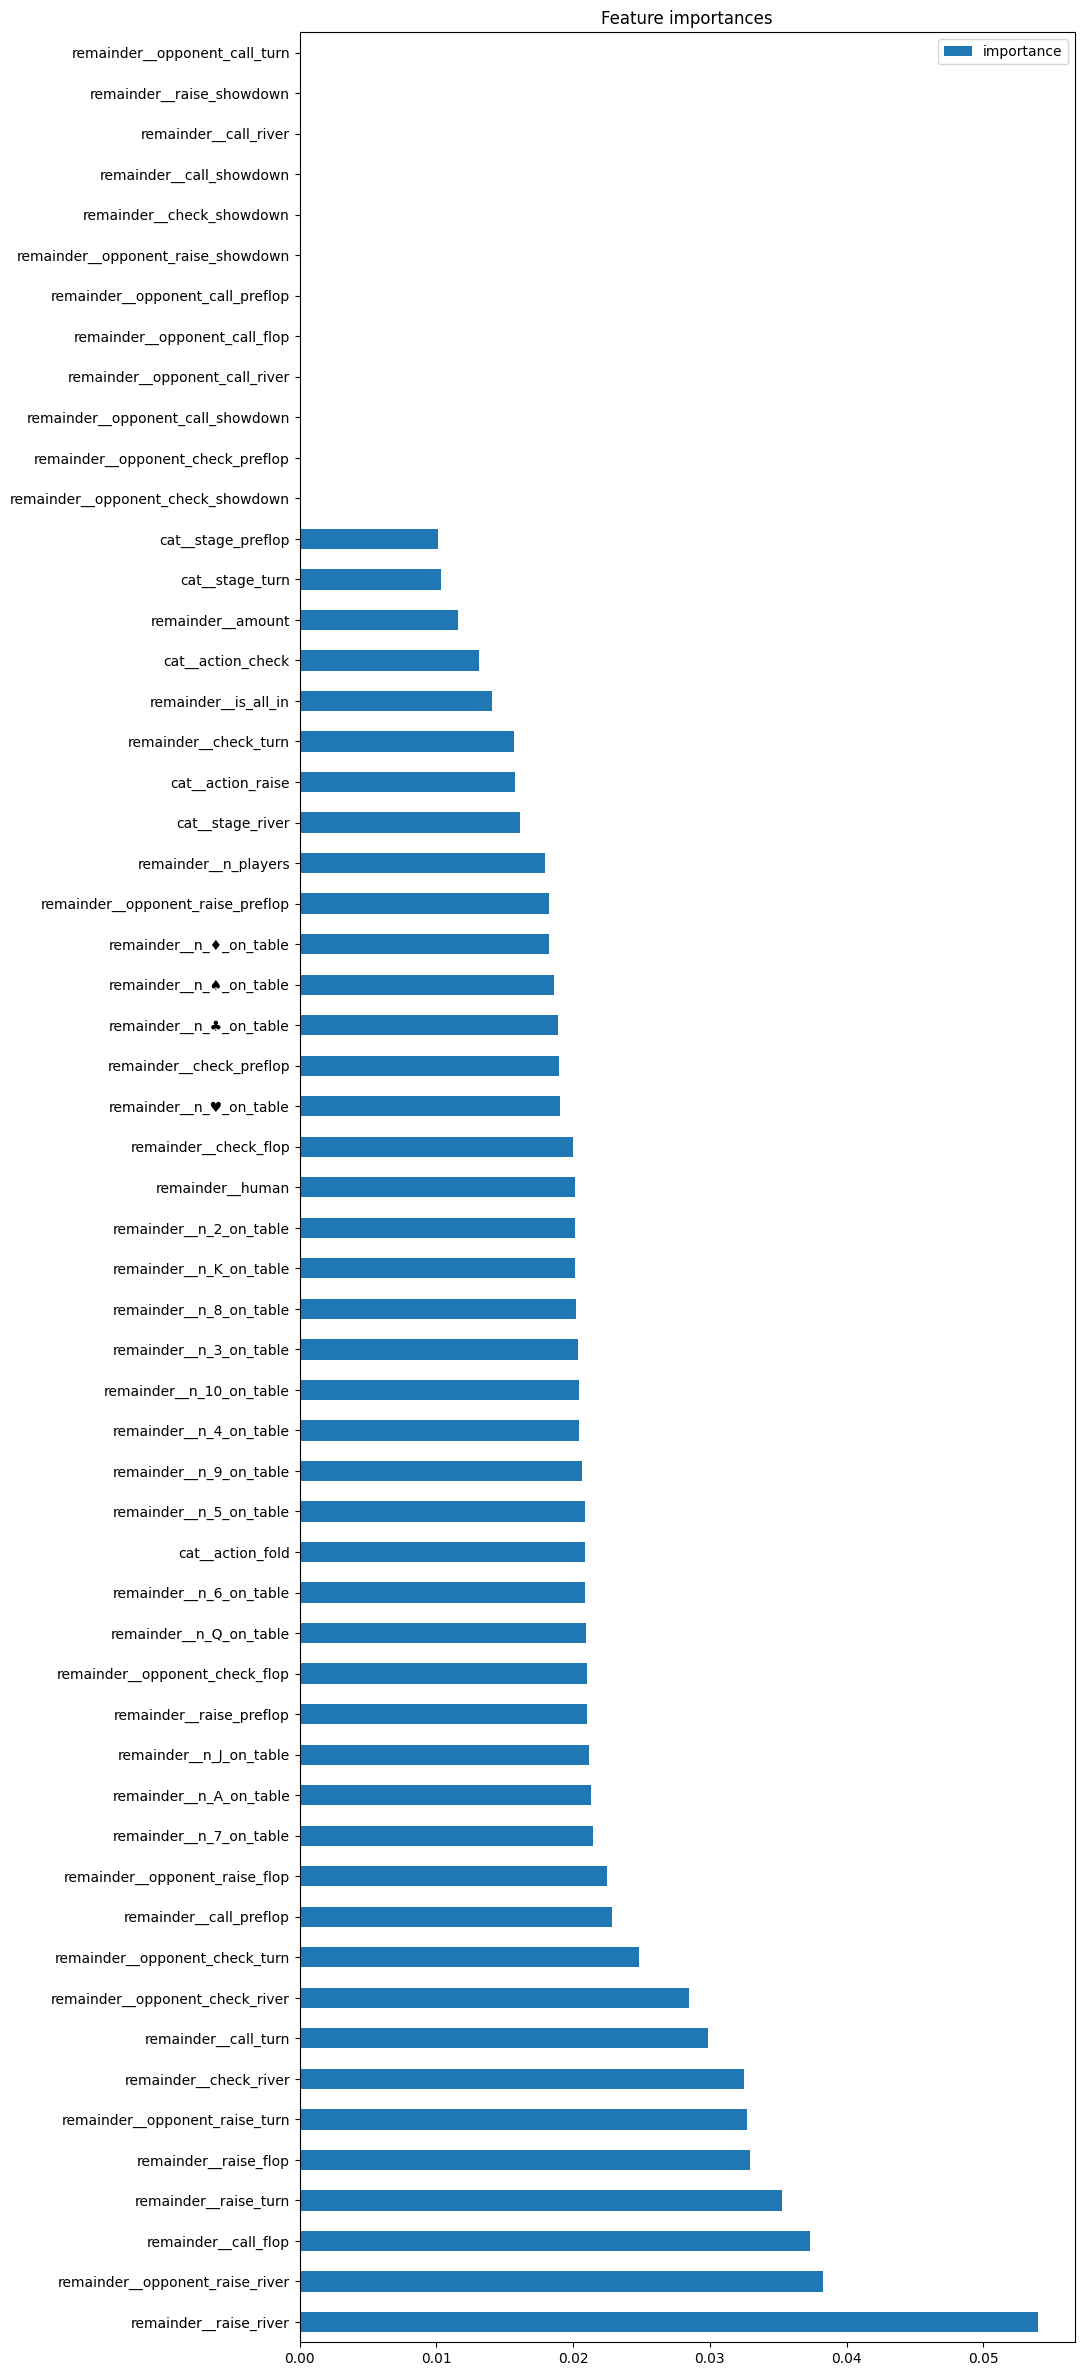

In [31]:
# Examine feature importances
importances = model.named_steps["classifier"].feature_importances_
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances_df = pd.DataFrame(importances, index=feature_names, columns=["importance"])
importances_df.sort_values("importance", ascending=False).plot(kind="barh", title="Feature importances", figsize=(10, 30))

## Compare to a neural network

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [33]:
# Convert target variable to categorical
y_train_cat = to_categorical(y_train_cls)
y_test_cat = to_categorical(y_test_cls)

In [34]:
# Convert categorical input features (`categorical_cols`) to one-hot encoding
X_train_cat = preprocessor.fit_transform(X_train)
X_test_cat = preprocessor.transform(X_test)

In [35]:
# Scale input features
scaler = StandardScaler()

# Step 2: Fit the scaler on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_cat)
X_test_scaled = scaler.transform(X_test_cat)

In [36]:
# Convert to tensors
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_cat_tensor = tf.convert_to_tensor(y_train_cat, dtype=tf.float32)
y_train_suited_tensor = tf.convert_to_tensor(Y_train["hand_suited"], dtype=tf.float32)
y_test_cat_tensor = tf.convert_to_tensor(y_test_cat, dtype=tf.float32)
y_test_suited_tensor = tf.convert_to_tensor(Y_test["hand_suited"], dtype=tf.float32)

# Expand dims to get (num_samples, 1) shape
y_train_suited_tensor = tf.expand_dims(y_train_suited_tensor, axis=-1)
y_test_suited_tensor = tf.expand_dims(y_test_suited_tensor, axis=-1)

2024-10-04 18:44:38.221675: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-10-04 18:44:38.221697: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-10-04 18:44:38.221702: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-10-04 18:44:38.221763: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-10-04 18:44:38.222057: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [37]:
# Define the input layer
input_layer = Input(shape=(X_train_tensor.shape[1],))

# Shared layers
x = Dense(512)(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# First output for hand groups
hand_group_output = Dense(91, activation="softmax", name="hand_group")(x)

# Second output for suited status
is_suited_output = Dense(1, activation="sigmoid", name="is_suited")(x)

# Define the model with two outputs
model_nn = Model(inputs=input_layer, outputs=[hand_group_output, is_suited_output])

# Compile the model with appropriate loss functions
model_nn.compile(
    optimizer=Adam(learning_rate=.01),
    loss={"hand_group": "categorical_crossentropy", "is_suited": "binary_crossentropy"},
    metrics=["accuracy"],
)

In [38]:
# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

In [39]:
# Train the model
model_nn.fit(
    X_train_tensor,
    {
        "hand_group": y_train_cat_tensor,
        "is_suited": y_train_suited_tensor,
    },
    epochs=30,
    batch_size=32,
    validation_data=(
        X_test_tensor,
        {"hand_group": y_test_cat_tensor, "is_suited": y_test_suited_tensor},
    ),
    # callbacks=[early_stopping],
)

Epoch 1/30


2024-10-04 18:44:41.617456: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


382/382 [==============================] - ETA: 0s - loss: 5.4969 - hand_group_loss: 4.9111 - is_suited_loss: 0.5858 - hand_group_accuracy: 0.0161 - is_suited_accuracy: 0.7620

2024-10-04 18:44:50.921156: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


382/382 [==============================] - 11s 25ms/step - loss: 5.4969 - hand_group_loss: 4.9111 - is_suited_loss: 0.5858 - hand_group_accuracy: 0.0161 - is_suited_accuracy: 0.7620 - val_loss: 5.1205 - val_hand_group_loss: 4.5255 - val_is_suited_loss: 0.5950 - val_hand_group_accuracy: 0.0160 - val_is_suited_accuracy: 0.7253
Epoch 2/30
382/382 [==============================] - 10s 25ms/step - loss: 5.0262 - hand_group_loss: 4.4830 - is_suited_loss: 0.5432 - hand_group_accuracy: 0.0172 - is_suited_accuracy: 0.7679 - val_loss: 5.0978 - val_hand_group_loss: 4.5017 - val_is_suited_loss: 0.5961 - val_hand_group_accuracy: 0.0125 - val_is_suited_accuracy: 0.7253
Epoch 3/30
382/382 [==============================] - 9s 24ms/step - loss: 5.0039 - hand_group_loss: 4.4614 - is_suited_loss: 0.5424 - hand_group_accuracy: 0.0165 - is_suited_accuracy: 0.7679 - val_loss: 5.0706 - val_hand_group_loss: 4.4754 - val_is_suited_loss: 0.5952 - val_hand_group_accuracy: 0.0188 - val_is_suited_accuracy: 0.725

In [40]:
# Evaluate the model
evaluation = model_nn.evaluate(
    X_test_tensor,
    {
        "hand_group": y_test_cat_tensor,
        "is_suited": y_test_suited_tensor,
    },
)
print(evaluation)
total_loss, hand_group_loss, suited_loss, hand_group_accuracy, suited_accuracy = evaluation
print(f"Total loss: {total_loss}")
print(f"Hand group loss: {hand_group_loss}")
print(f"Suited loss: {suited_loss}")
print(f"Hand group accuracy: {hand_group_accuracy}")
print(f"Suited accuracy: {suited_accuracy}")

100/100 [==============================] - 1s 11ms/step - loss: 5.0693 - hand_group_loss: 4.4741 - is_suited_loss: 0.5952 - hand_group_accuracy: 0.0216 - is_suited_accuracy: 0.7253
[5.069250583648682, 4.474087238311768, 0.5951628088951111, 0.0215894877910614, 0.7252815961837769]
Total loss: 5.069250583648682
Hand group loss: 4.474087238311768
Suited loss: 0.5951628088951111
Hand group accuracy: 0.0215894877910614
Suited accuracy: 0.7252815961837769


In [41]:
from cpp_poker.cpp_poker import HandGroup

class_preds, suitedness_preds = model_nn.predict(X_test_tensor)
class_labels = [
    tuple((Card.VALUES[rank] for rank in group))
    for group in HandGroup.UNSUITED_COMBINATIONS
]

 34/100 [=========>....................] - ETA: 0s

2024-10-04 18:50:09.034400: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


100/100 [==============================] - 0s 3ms/step


(array([ 396.,    0.,    0.,    0.,    0.,    0.,    9.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 1892.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,   32.,    0.,   95.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,  667.,    0.,    0.,
         105.]),
 array([ 1.        ,  1.8021978 ,  2.6043956 ,  3.40659341,  4.20879121,
         5.01098901,  5.81318681,  6.61538462,  7.41758242,  8.21978022,
         9.02197802,  9.82417582, 10.62637363, 11.42857143, 12.23076923,
        13.03296703, 13.83516484, 14.63736264, 15.4395

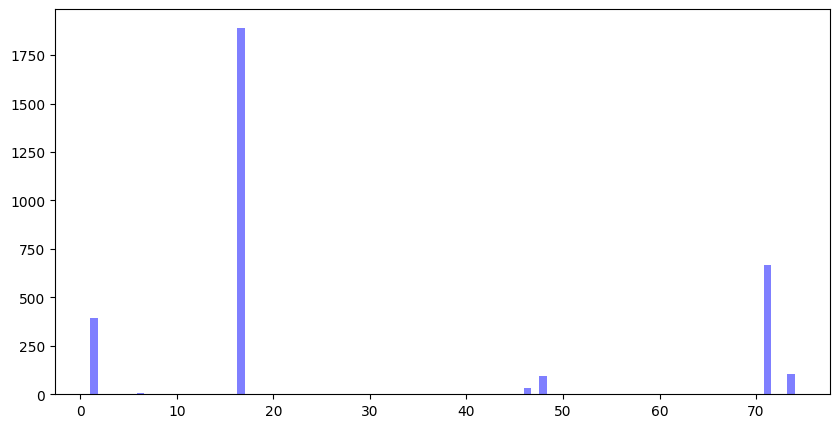

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(
    class_preds.argmax(axis=1),
    bins=len(class_labels),
    alpha=0.5,
    label="Predicted",
    color="blue",
)

In [44]:
# Look at the prediction of single rows
from IPython.display import clear_output

i = 0
while i < len(y_test_cat_tensor):
    class_pred = class_preds[i]
    suitedness_pred = suitedness_preds[i][0]
    print(f"Predicted class: {class_labels[np.argmax(class_pred)]}")
    print(f"Predicted prob for predicted class: {class_pred[np.argmax(class_pred)]}")
    true_group_unsuited = np.argmax(y_test_cat_tensor[i])
    print("True class:", class_labels[true_group_unsuited])
    print(f"Prob for true class: {class_pred[true_group_unsuited]}")
    print()
    print(f"Prob suited: {suitedness_pred}")
    print(f"Was suited?: {y_test_suited_tensor[i].numpy()}")
    print()
    print("Predicted probabilities:")
    print(
        pd.DataFrame(
            dict(zip(class_labels, class_pred)), index=["probability"]
        ).T.sort_values("probability", ascending=False)
    )
    if input("Continue? (Y/n)").lower()[:1] == "n":
        break
    i += 1
    clear_output(wait=True)

Predicted class: ('7', '6')
Predicted prob for predicted class: 0.01713777706027031
True class: ('Q', '2')
Prob for true class: 0.012668566778302193

Prob suited: 0.21790656447410583
Was suited?: [0.]

Predicted probabilities:
       probability
7  6      0.017138
10 8      0.016643
   6      0.015883
K  6      0.015567
Q  6      0.015521
...            ...
8  8      0.002140
K  K      0.001966
10 10     0.001518
Q  Q      0.000937
A  A      0.000784

[91 rows x 1 columns]
